<a href="https://colab.research.google.com/github/duryupin/ml_trading/blob/main/main_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install moexalgo -q
!pip install pandas-ta -q
!pip install jupyter_contrib_nbextensions -q
#!pip install numpy==1.26.4

## Библиотеки

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from datetime import datetime, timedelta

import pandas_ta as ta

import pandas_datareader.data as web

import seaborn as sns

import moexalgo

import lightgbm as lgb

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.regression.rolling import RollingOLS
import statsmodels.api as sm

from scipy.stats import randint, uniform

import warnings

import requests

from bs4 import BeautifulSoup

import time

warnings.filterwarnings("ignore")

# Graphics in SVG format are more sharp and legible
%config InlineBackend.figure_format = 'svg'

sns.set_theme(rc={'figure.figsize':(12, 6)})
#sns.set_palette("viridis")

pd.set_option('display.max_columns', None)

%matplotlib inline

## Загрузка данных

In [3]:
START_DATE = pd.to_datetime('2014-01-01')
END_DATE = datetime.now()
TICKER='CHMF'

In [4]:
stock = moexalgo.Ticker(TICKER)
data_d = pd.DataFrame(stock.candles(
    start=START_DATE,
    end=END_DATE,
    period='1d'
            ))

In [5]:
data_d.set_index('begin', inplace=True)

In [6]:
data_d.head()

,open,close,high,low,value,volume,end
begin,,,,,,,
2014-06-09,297.0,296.5,305.0,295.0,544321251.0,1814130.0,2014-06-09 23:59:59
2014-06-10,297.5,293.4,297.5,291.1,282784084.0,963070.0,2014-06-10 23:59:59
2014-06-11,293.2,292.5,296.7,290.0,238429396.0,816920.0,2014-06-11 23:59:59
2014-06-16,290.1,285.4,290.9,282.7,681333222.0,2377230.0,2014-06-16 23:59:59
2014-06-17,285.4,286.5,291.2,284.6,404236588.0,1404850.0,2014-06-17 23:59:59


In [8]:
weekly = data_d.resample('W').last()['close']

In [9]:
weekly.head()

,close
begin,
2014-06-15,292.5
2014-06-22,286.2
2014-06-29,280.6
2014-07-06,283.4
2014-07-13,290.9


In [10]:
outlier_cutoff = 0.01
data = pd.DataFrame()
lags = [1, 2, 3, 6, 9, 12]

In [11]:
for lag in lags:
    data[f'return_{lag}w'] = (weekly.pct_change(lag)
    .pipe(lambda x: x.clip(lower=x.quantile(outlier_cutoff),
                            upper=x.quantile(1-outlier_cutoff)))
    .add(1)
    .pow(1/lag)
    .sub(1)
    )

In [12]:
data = data.dropna()
data.head()

,return_1w,return_2w,return_3w,return_6w,return_9w,return_12w
begin,,,,,,
2014-09-07,0.026426,0.011861,0.026353,0.029408,0.029761,0.019550
2014-09-14,-0.006233,0.009964,0.005793,0.010267,0.026063,0.020869
2014-09-21,0.046359,0.019724,0.021953,0.023338,0.026961,0.026421
2014-09-28,0.018243,0.032206,0.019230,0.022785,0.026004,0.027118
2014-10-05,-0.025723,-0.003982,0.012523,0.009153,0.011019,0.022661


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 569 entries, 2014-09-07 to 2025-07-27
Freq: W-SUN
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   return_1w   569 non-null    float64
 1   return_2w   569 non-null    float64
 2   return_3w   569 non-null    float64
 3   return_6w   569 non-null    float64
 4   return_9w   569 non-null    float64
 5   return_12w  569 non-null    float64
dtypes: float64(6)
memory usage: 31.1 KB


In [14]:
for lag in [2,3,6,9,12]:
  data[f'momentum_{lag}'] = data[f'return_{lag}w'].sub(data.return_1w)

In [ ]:
#data[f'momentum_3_12'] = data[f'return_12w'].sub(data.return_3w)

In [ ]:
#data[f'momentum_3_9'] = data[f'return_9w'].sub(data.return_3w)

In [15]:
data.head()

,return_1w,return_2w,return_3w,return_6w,return_9w,return_12w,momentum_2,momentum_3,momentum_6,momentum_9,momentum_12
begin,,,,,,,,,,,
2014-09-07,0.026426,0.011861,0.026353,0.029408,0.029761,0.019550,-0.014565,-0.000073,0.002982,0.003335,-0.006876
2014-09-14,-0.006233,0.009964,0.005793,0.010267,0.026063,0.020869,0.016197,0.012026,0.016500,0.032296,0.027102
2014-09-21,0.046359,0.019724,0.021953,0.023338,0.026961,0.026421,-0.026635,-0.024406,-0.023021,-0.019399,-0.019939
2014-09-28,0.018243,0.032206,0.019230,0.022785,0.026004,0.027118,0.013962,0.000987,0.004542,0.007761,0.008874
2014-10-05,-0.025723,-0.003982,0.012523,0.009153,0.011019,0.022661,0.021741,0.038246,0.034876,0.036742,0.048384


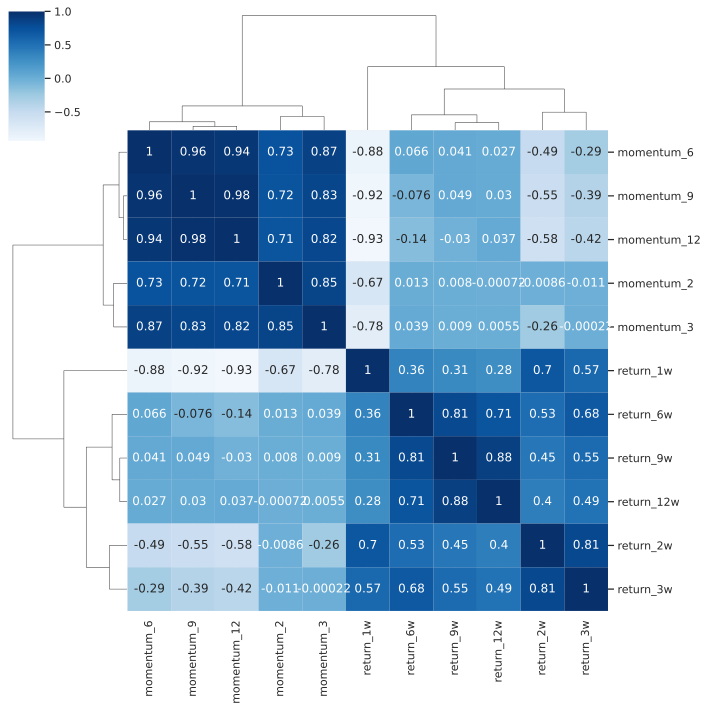

In [16]:
sns.clustermap(data.corr('spearman'), annot=True, center=0, cmap='Blues');

In [18]:
dates = data.index.get_level_values('begin')
data['year'] = dates.year
data['month'] = dates.month


In [21]:
data['week_day'] = dates.weekday

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 569 entries, 2014-09-07 to 2025-07-27
Freq: W-SUN
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   return_1w    569 non-null    float64
 1   return_2w    569 non-null    float64
 2   return_3w    569 non-null    float64
 3   return_6w    569 non-null    float64
 4   return_9w    569 non-null    float64
 5   return_12w   569 non-null    float64
 6   momentum_2   569 non-null    float64
 7   momentum_3   569 non-null    float64
 8   momentum_6   569 non-null    float64
 9   momentum_9   569 non-null    float64
 10  momentum_12  569 non-null    float64
 11  year         569 non-null    int32  
 12  month        569 non-null    int32  
 13  week_day     569 non-null    int32  
dtypes: float64(11), int32(3)
memory usage: 60.0 KB


In [24]:
for t in range(1, 7):
  data[f'return_1w_t-{t}'] = data.return_1w.shift(t)

In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 569 entries, 2014-09-07 to 2025-07-27
Freq: W-SUN
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   return_1w      569 non-null    float64
 1   return_2w      569 non-null    float64
 2   return_3w      569 non-null    float64
 3   return_6w      569 non-null    float64
 4   return_9w      569 non-null    float64
 5   return_12w     569 non-null    float64
 6   momentum_2     569 non-null    float64
 7   momentum_3     569 non-null    float64
 8   momentum_6     569 non-null    float64
 9   momentum_9     569 non-null    float64
 10  momentum_12    569 non-null    float64
 11  year           569 non-null    int32  
 12  month          569 non-null    int32  
 13  week_day       569 non-null    int32  
 14  return_1w_t-1  568 non-null    float64
 15  return_1w_t-2  567 non-null    float64
 16  return_1w_t-3  566 non-null    float64
 17  return_1w_t-4  565 non-

In [26]:
data.ta.indicators()

Pandas TA - Technical Analysis Indicators - v0.3.14b0
Total Indicators & Utilities: 205
Abbreviations:
    aberration, above, above_value, accbands, ad, adosc, adx, alma, amat, ao, aobv, apo, aroon, atr, bbands, below, below_value, bias, bop, brar, cci, cdl_pattern, cdl_z, cfo, cg, chop, cksp, cmf, cmo, coppock, cross, cross_value, cti, decay, decreasing, dema, dm, donchian, dpo, ebsw, efi, ema, entropy, eom, er, eri, fisher, fwma, ha, hilo, hl2, hlc3, hma, hwc, hwma, ichimoku, increasing, inertia, jma, kama, kc, kdj, kst, kurtosis, kvo, linreg, log_return, long_run, macd, mad, massi, mcgd, median, mfi, midpoint, midprice, mom, natr, nvi, obv, ohlc4, pdist, percent_return, pgo, ppo, psar, psl, pvi, pvo, pvol, pvr, pvt, pwma, qqe, qstick, quantile, rma, roc, rsi, rsx, rvgi, rvi, short_run, sinwma, skew, slope, sma, smi, squeeze, squeeze_pro, ssf, stc, stdev, stoch, stochrsi, supertrend, swma, t3, td_seq, tema, thermo, tos_stdevall, trima, trix, true_range, tsi, tsignals, ttm_trend, ui, 

In [27]:
help(ta.bbands)

Help on function bbands in module pandas_ta.volatility.bbands:

bbands(close, length=None, std=None, ddof=0, mamode=None, talib=None, offset=None, **kwargs)
    Bollinger Bands (BBANDS)
    
    A popular volatility indicator by John Bollinger.
    
    Sources:
        https://www.tradingview.com/wiki/Bollinger_Bands_(BB)
    
    Calculation:
        Default Inputs:
            length=5, std=2, mamode="sma", ddof=0
        EMA = Exponential Moving Average
        SMA = Simple Moving Average
        STDEV = Standard Deviation
        stdev = STDEV(close, length, ddof)
        if "ema":
            MID = EMA(close, length)
        else:
            MID = SMA(close, length)
    
        LOWER = MID - std * stdev
        UPPER = MID + std * stdev
    
        BANDWIDTH = 100 * (UPPER - LOWER) / MID
        PERCENT = (close - LOWER) / (UPPER - LOWER)
    
    Args:
        close (pd.Series): Series of 'close's
        length (int): The short period. Default: 5
        std (int): The long 

In [28]:
macd = data_d.ta.macd(fast=12, slow=21, signal=9).tail(20)

In [29]:
macd.head()

,MACD_12_21_9,MACDh_12_21_9,MACDs_12_21_9
begin,,,
2025-07-08,2.431381,-2.605680,5.037061
2025-07-09,1.154857,-3.105763,4.260620
2025-07-10,-0.321559,-3.665743,3.344184
2025-07-11,-2.648570,-4.794203,2.145633
2025-07-12,-3.935801,-4.865147,0.929347


In [ ]:
CommonStrategy = ta.CommonStrategy
print("name =", CommonStrategy.name)
print("description =", CommonStrategy.description)
print("created =", CommonStrategy.created)
print("ta =", CommonStrategy.ta)

name = Common Price and Volume SMAs
description = Common Price SMAs: 10, 20, 50, 200 and Volume SMA: 20.
created = Friday April 4, 2025, NYSE: 8:36:49, Local: 12:36:49 UTC, Day 94/365 (26.00%)
ta = [{'kind': 'sma', 'length': 10}, {'kind': 'sma', 'length': 20}, {'kind': 'sma', 'length': 50}, {'kind': 'sma', 'length': 200}, {'kind': 'sma', 'close': 'volume', 'length': 20, 'prefix': 'VOL'}]


In [31]:
w_bband = ta.bbands(weekly)

In [32]:
w_bband.tail()

,BBL_5_2.0,BBM_5_2.0,BBU_5_2.0,BBB_5_2.0,BBP_5_2.0
begin,,,,,
2025-06-29,966.585561,1003.16,1039.734439,7.291846,0.812240
2025-07-06,982.648191,1016.24,1049.831809,6.610999,0.859611
2025-07-13,967.693134,1010.08,1052.466866,8.392774,0.194717
2025-07-20,976.744840,1021.08,1065.415160,8.683974,0.769763
2025-07-27,976.500292,1020.96,1065.419708,8.709393,0.367745


In [33]:
w_rsi = ta.rsi(weekly)

In [34]:
w_rsi.tail()

,RSI_14
begin,
2025-06-29,40.690887
2025-07-06,42.275164
2025-07-13,38.007965
2025-07-20,44.531137
2025-07-27,41.745667


In [35]:
data_plot = pd.DataFrame({
    'bb_up': w_bband['BBU_5_2.0'],
    'bb_mid': w_bband['BBM_5_2.0'],
    'bb_low': w_bband['BBL_5_2.0'],
    'rsi': w_rsi})

In [36]:
data_plot.tail()

,bb_up,bb_mid,bb_low,rsi
begin,,,,
2025-06-29,1039.734439,1003.16,966.585561,40.690887
2025-07-06,1049.831809,1016.24,982.648191,42.275164
2025-07-13,1052.466866,1010.08,967.693134,38.007965
2025-07-20,1065.415160,1021.08,976.744840,44.531137
2025-07-27,1065.419708,1020.96,976.500292,41.745667


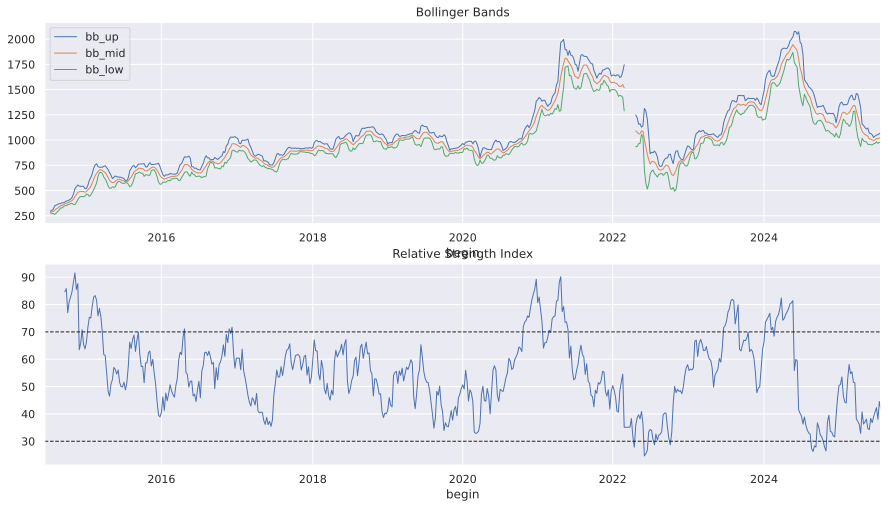

In [37]:
fig, axes= plt.subplots(nrows=2, figsize=(15, 8))
data_plot.drop('rsi', axis=1).plot(ax=axes[0], lw=1, title='Bollinger Bands')
data_plot['rsi'].plot(ax=axes[1], lw=1, title='Relative Strength Index')
axes[1].axhline(70, lw=1, ls='--', c='k')
axes[1].axhline(30, lw=1, ls='--', c='k')
plt.show()

In [38]:
data_d.head()

,open,close,high,low,value,volume,end
begin,,,,,,,
2014-06-09,297.0,296.5,305.0,295.0,544321251.0,1814130.0,2014-06-09 23:59:59
2014-06-10,297.5,293.4,297.5,291.1,282784084.0,963070.0,2014-06-10 23:59:59
2014-06-11,293.2,292.5,296.7,290.0,238429396.0,816920.0,2014-06-11 23:59:59
2014-06-16,290.1,285.4,290.9,282.7,681333222.0,2377230.0,2014-06-16 23:59:59
2014-06-17,285.4,286.5,291.2,284.6,404236588.0,1404850.0,2014-06-17 23:59:59


In [40]:
result = data_d.merge(data, left_index=True, right_index=True, how='left')

In [42]:
result.tail(10)

,open,close,high,low,value,volume,end,return_1w,return_2w,return_3w,return_6w,return_9w,return_12w,momentum_2,momentum_3,momentum_6,momentum_9,momentum_12,year,month,week_day,return_1w_t-1,return_1w_t-2,return_1w_t-3,return_1w_t-4,return_1w_t-5,return_1w_t-6
begin,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-07-18,1018.0,1040.6,1057.0,1017.0,2.034903e+09,1961130.0,2025-07-18 23:59:56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-19,1041.0,1042.8,1051.0,1038.0,1.797715e+08,172333.0,2025-07-19 23:59:57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-20,1046.0,1045.0,1047.6,1040.8,8.688676e+07,83220.0,2025-07-20 23:59:57,0.061776,0.002208,0.006135,0.004867,0.000021,-0.004792,-0.059568,-0.055641,-0.056910,-0.061755,-0.066568,2025.0,7.0,6.0,-0.054018,0.014035,0.016043,0.020000,-0.024631,0.041026
2025-07-21,1042.6,1042.6,1054.0,1026.4,1.694203e+09,1629619.0,2025-07-21 23:59:57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-22,1040.0,1061.2,1072.4,1035.6,1.339931e+09,1268300.0,2025-07-22 23:59:59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-23,1061.0,1040.0,1066.2,1035.2,1.148634e+09,1095120.0,2025-07-23 23:59:59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-24,1040.2,1031.8,1045.6,1015.8,1.248589e+09,1215570.0,2025-07-24 23:59:55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-25,1029.0,1008.6,1037.6,1006.0,9.197571e+08,900206.0,2025-07-25 23:59:57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-26,1013.2,1012.4,1013.2,1009.0,2.488809e+07,24624.0,2025-07-26 23:59:57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
for column in ['open_weekly', 'high_weekly', 'low_weekly', 'close_weekly', 'volume_weekly']:
    result[column] = result[column].fillna(result[column].groupby(pd.Grouper(freq='W')).transform('first'))

In [ ]:
result.head(10)

In [ ]:
result['vwap'] = (result['close'] * result['volume']).cumsum() / result['volume'].cumsum()
result['vwap_weekly'] = (result['close_weekly'] * result['volume_weekly']).cumsum() / result['volume_weekly'].cumsum()

In [ ]:
result.head()

In [ ]:
def price_volume(df, price='vwap', vol='volume', suptitle='title', fname=None):

    fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(15,8))
    axes[0].plot(df.index, df[price])
    axes[1].bar(df.index, df[vol], width=1/(4*len(df.index)), color='red')

    # formatting
    #xfmt = mpl.dates.DateFormatter('%H:%M')
    #axes[1].xaxis.set_major_locator(mpl.dates.HourLocator(interval=3))
    #axes[1].xaxis.set_major_formatter(MaxNLocator(nbins=10))
    #axes[1].get_xaxis().set_tick_params(which='major', pad=25)
    axes[0].set_title('Price', fontsize=14)
    axes[1].set_title('Volume', fontsize=14)
    fig.autofmt_xdate()
    fig.suptitle(suptitle)
    fig.tight_layout()
    plt.subplots_adjust(top=0.9);

In [ ]:
price_volume(result)

## Парсинг

In [50]:
url = 'https://smart-lab.ru/q/CHMF/f/y/RSBU/'

# Заголовки, чтобы замаскироваться под браузер
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.36"
}

# Скачиваем HTML страницы при помощи requests
response = requests.get(url, headers=headers)

soup = BeautifulSoup(response.text, 'html.parser')

In [51]:
table = soup.find('table', class_='financials')

In [61]:
data = {
    'year': ['2020', '2021', '2022', '2023', '2024', '', ''],
    'net_income': [],
    'shares': [],
    'net_intrst_incm': [],
    'p_e': [],
    'p_b': []
}

In [66]:
def find_row_data(field_name):
    row = table.find('tr', attrs={'field': field_name})
    if row:
        return [td.get_text(strip=True) for td in row.find_all('td')[1:8]]
    return [None]*7

In [67]:
data['net_income'] = find_row_data('net_income')
data['shares'] = find_row_data('number_of_shares')
data['net_intrst_incm'] = find_row_data('net_interest_income')
data['p_e'] = find_row_data('p_e')
data['p_b'] = find_row_data('p_b')

In [68]:
data

{'year': ['2020', '2021', '2022', '2023', '2024', '', ''],
 'net_income': ['114.9', '272.9', '153.0', '159.2', '115.9', '', '88.9'],
 'shares': ['837.7', '837.7', '837.7', '837.7', '837.7', '', '837.7'],
 'net_intrst_incm': [None, None, None, None, None, None, None],
 'p_e': ['9.62', '4.93', '4.93', '7.36', '9.44', '', '9.49'],
 'p_b': [None, None, None, None, None, None, None]}

In [69]:
df_fundament = pd.DataFrame(data)

In [70]:
df_fundament

,year,net_income,shares,net_intrst_incm,p_e,p_b
0,2020,114.9,837.7,None,9.62,None
1,2021,272.9,837.7,None,4.93,None
2,2022,153.0,837.7,None,4.93,None
3,2023,159.2,837.7,None,7.36,None
4,2024,115.9,837.7,None,9.44,None
5,,,,None,,None
6,,88.9,837.7,None,9.49,None


In [71]:
numeric_columns = ['net_income', 'shares', 'net_intrst_incm', 'p_e', 'p_b']
for col in numeric_columns:
  df_fundament[col] = pd.to_numeric(df_fundament[col].str.replace(' ', '').str.replace(',', '.'), errors='coerce')

In [72]:
df_fundament

,year,net_income,shares,net_intrst_incm,p_e,p_b
0,2020,114.9,837.7,NaN,9.62,NaN
1,2021,272.9,837.7,NaN,4.93,NaN
2,2022,153.0,837.7,NaN,4.93,NaN
3,2023,159.2,837.7,NaN,7.36,NaN
4,2024,115.9,837.7,NaN,9.44,NaN
5,,NaN,NaN,NaN,NaN,NaN
6,,88.9,837.7,NaN,9.49,NaN
